# 국립중앙박물관 유료입장 전환 시 최적 입장료 분석
## Step 2: 리뷰 감성분석 + 토픽모델링

**목적**: 세계 주요 박물관 리뷰를 분석하여 방문객이 가치를 느끼는 요소와 가격 민감도를 파악한다.

**분석 흐름**:
1. 데이터 로드 & 전처리
2. 감성분석 (사전 기반)
3. 토픽모델링 (LDA)
4. 유료 vs 무료 박물관 비교
5. 인사이트 도출

**필요 라이브러리**: pandas, numpy, sklearn, matplotlib, seaborn

> **Note**: VADER/TextBlob 사용 가능 시 감성분석 정확도를 높일 수 있음.
> `pip install vaderSentiment textblob`

## 0. 환경 설정

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

DATA_DIR = '../data/'
OUTPUT_DIR = '../output/'

## 1. 데이터 로드 & 전처리

In [2]:
# 리뷰 데이터 로드
df = pd.read_csv(f'{DATA_DIR}museum_review.csv')
print(f'전체 리뷰: {len(df)}')
print(f'컬럼: {df.columns.tolist()}')
print(f'박물관 수: {df["museum_id"].nunique()}')
print(f'텍스트 없는 리뷰: {df["text"].isna().sum()}')

# 텍스트 없는 리뷰 제거
df = df[df['text'].notna()].copy()
df['text'] = df['text'].astype(str)
print(f'\n분석 대상 리뷰: {len(df)}')

# 별점 분포
print(f'\n별점 분포:')
print(df['stars'].value_counts().sort_index())

# 박물관별 리뷰 수
print(f'\n박물관별 리뷰 수:')
print(df.groupby('museum_id').size().sort_values(ascending=False))
print(df.describe())

전체 리뷰: 4119
컬럼: ['title', 'museum_id', 'stars', 'text', 'id']
박물관 수: 21
텍스트 없는 리뷰: 65

분석 대상 리뷰: 4054

별점 분포:
stars
1      90
2      59
3     140
4     460
5    3305
Name: count, dtype: int64

박물관별 리뷰 수:
museum_id
1001    200
1012    200
1023    200
1020    200
1019    200
1018    200
1017    200
1016    200
1014    200
1013    200
1024    200
1002    200
1010    200
1009    200
1008    200
1007    200
1005    200
1004    200
1003    200
1011    162
1006     92
dtype: int64
         museum_id        stars           id
count  4054.000000  4054.000000  4054.000000
mean   1011.675876     4.685002  2066.305624
std       6.826027     0.799202  1196.020864
min    1001.000000     1.000000     1.000000
25%    1006.000000     5.000000  1017.250000
50%    1011.000000     5.000000  2062.500000
75%    1017.000000     5.000000  3105.750000
max    1024.000000     5.000000  4119.000000


## 2. 감성분석 (Dictionary-based)

긍정/부정 단어 사전을 기반으로 각 리뷰의 감성 점수를 산출한다.

- 점수 범위: -1 (매우 부정) ~ +1 (매우 긍정)
- 계산: (긍정 단어 수 - 부정 단어 수) / (긍정 + 부정 단어 수)

> **업그레이드 옵션**: VADER나 HuggingFace `nlptown/bert-base-multilingual-uncased-sentiment` 모델을 쓰면 다국어 지원 + 더 높은 정확도

In [3]:
# 긍정/부정 단어 사전
positive_words = set([
    'amazing','wonderful','beautiful','excellent','fantastic','incredible','outstanding',
    'stunning','magnificent','brilliant','superb','perfect','love','loved','great',
    'best','awesome','impressive','remarkable','extraordinary','fascinating','enjoyable',
    'recommend','recommended','worth','worthwhile','treasure','masterpiece','spectacular',
    'lovely','delightful','charming','elegant','breathtaking','phenomenal','splendid',
    'fabulous','marvelous','exceptional','terrific','must','interesting','nice','good',
    'happy','pleased','satisfied','enjoy','enjoyed','favorite','favourite','glad','free',
    'clean','friendly','helpful','informative','rich','vast','huge','immersive','inspiring'
])

negative_words = set([
    'disappointing','disappointed','terrible','horrible','awful','worst','bad','poor',
    'boring','overrated','crowded','expensive','overpriced','waste','rude','unfriendly',
    'dirty','confusing','annoying','frustrating','mediocre','underwhelming','unpleasant',
    'tired','exhausting','chaotic','disorganized','closed','broken','slow','long',
    'queue','wait','waiting','theft','stolen','scam','robbery','noisy','loud',
    'uncomfortable','inaccessible','small','limited','lacking','nothing','avoid',
    'complained','complaint','worse','ugly','stressful','tiring','inconvenient'
])

def sentiment_score(text):
    """리뷰 텍스트의 감성 점수를 계산. -1(부정) ~ +1(긍정)"""
    words = re.findall(r'\b[a-zA-Z]+\b', text.lower())
    if len(words) == 0:
        return 0.0
    pos = sum(1 for w in words if w in positive_words)
    neg = sum(1 for w in words if w in negative_words)
    total = pos + neg
    if total == 0:
        return 0.0
    return (pos - neg) / total

# 감성 점수 계산
df['sentiment'] = df['text'].apply(sentiment_score)
df['sentiment_label'] = pd.cut(
    df['sentiment'], 
    bins=[-1.01, -0.2, 0.2, 1.01],
    labels=['negative', 'neutral', 'positive']
)

print('감성 분포:')
print(df['sentiment_label'].value_counts())
print(f'\n감성-별점 상관계수: {df["sentiment"].corr(df["stars"]):.3f}')

감성 분포:
sentiment_label
positive    3235
neutral      631
negative     188
Name: count, dtype: int64

감성-별점 상관계수: 0.358


In [4]:
# 박물관별 감성 요약
# museum_info와 조인해서 박물관 이름 추가
info = pd.read_csv(f'{DATA_DIR}museum_info.csv')
id_name = info[['id', 'museum', 'adult_price_local_usd', 'admission_free_yn']]

museum_sent = df.groupby('museum_id').agg(
    avg_sentiment=('sentiment', 'mean'),
    avg_stars=('stars', 'mean'),
    review_count=('text', 'count'),
    positive_pct=('sentiment_label', lambda x: (x == 'positive').mean() * 100),
    negative_pct=('sentiment_label', lambda x: (x == 'negative').mean() * 100),
).round(2).reset_index()

museum_sent = museum_sent.merge(id_name, left_on='museum_id', right_on='id', how='left')

print('=== 박물관별 감성 랭킹 ===')
cols = ['museum', 'avg_sentiment', 'avg_stars', 'positive_pct', 'negative_pct', 'admission_free_yn']
print(museum_sent.sort_values('avg_sentiment', ascending=False)[cols].to_string(index=False))

=== 박물관별 감성 랭킹 ===
                                 museum  avg_sentiment  avg_stars  positive_pct  negative_pct admission_free_yn
Museum of New Zealand Te Papa Tongarewa           0.90       4.76         95.00          1.00                 Y
             Victoria and Albert Museum           0.88       4.86         94.50          1.50                 Y
                       National Gallery           0.88       4.84         94.50          0.50                 Y
            National Museum of Scotland           0.87       4.91         94.50          1.00                 Y
               National Museum of Korea           0.86       4.85         93.50          0.50                 Y
                National Gallery of Art           0.82       4.88         89.50          2.50                 Y
                  Tokyo National Museum           0.80       4.81         88.00          4.00                 N
                             MMCA Seoul           0.76       4.53         83.00      

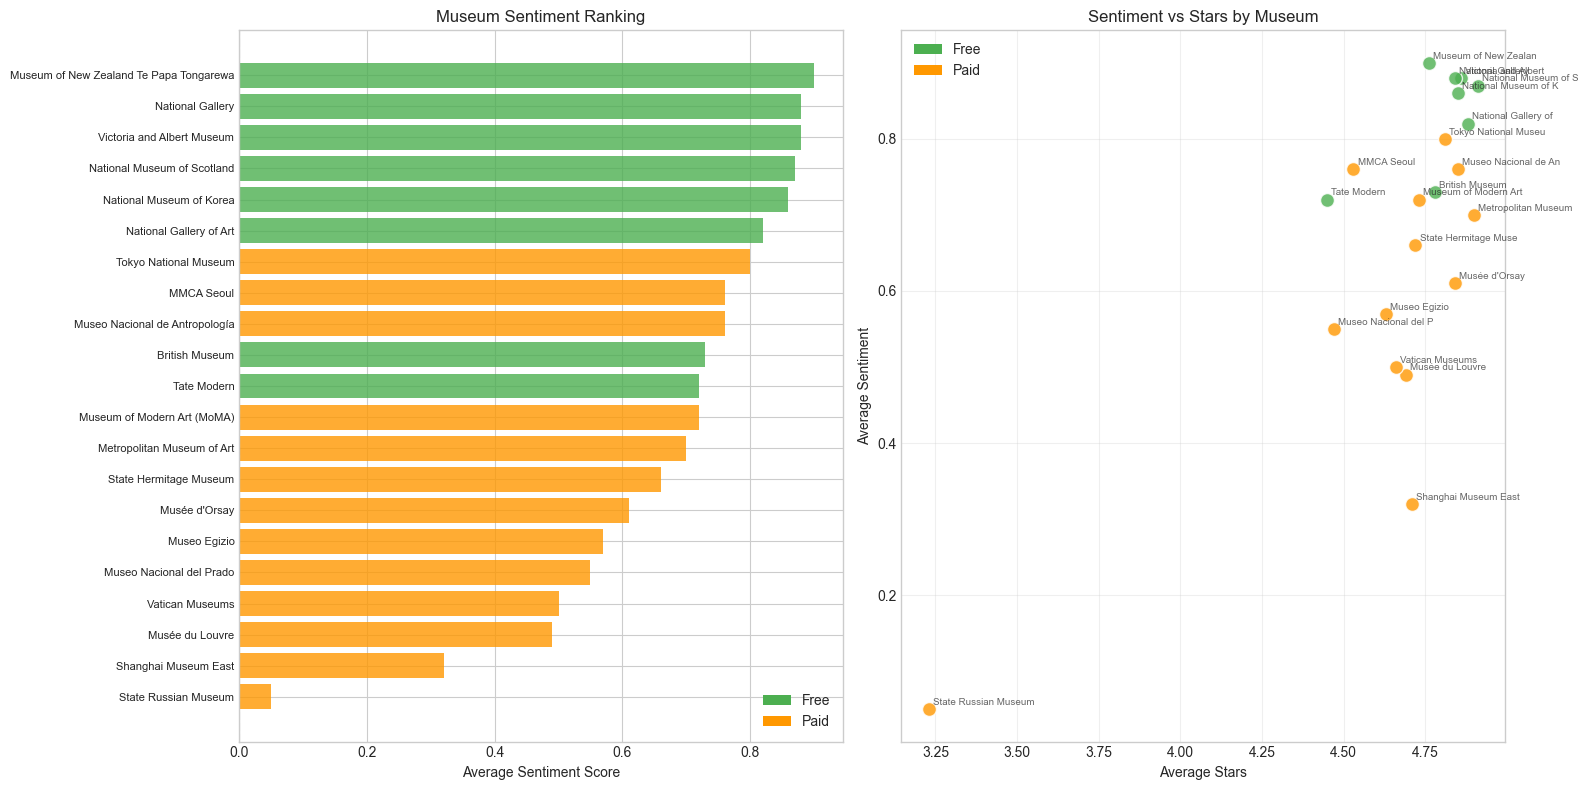

In [5]:
# 감성 점수 시각화: 박물관별 비교
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# 감성 점수 바 차트
sorted_sent = museum_sent.sort_values('avg_sentiment', ascending=True)
colors = ['#4CAF50' if x == 'Y' else '#FF9800' for x in sorted_sent['admission_free_yn']]

ax1.barh(range(len(sorted_sent)), sorted_sent['avg_sentiment'], color=colors, alpha=0.8)
ax1.set_yticks(range(len(sorted_sent)))
ax1.set_yticklabels(sorted_sent['museum'], fontsize=8)
ax1.set_xlabel('Average Sentiment Score')
ax1.set_title('Museum Sentiment Ranking')
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

# 범례
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4CAF50', label='Free'),
                   Patch(facecolor='#FF9800', label='Paid')]
ax1.legend(handles=legend_elements, loc='lower right')

# 감성 vs 별점 산점도
for _, r in museum_sent.iterrows():
    color = '#4CAF50' if r['admission_free_yn'] == 'Y' else '#FF9800'
    ax2.scatter(r['avg_stars'], r['avg_sentiment'], c=color, s=100, alpha=0.8, edgecolors='white')
    ax2.annotate(r['museum'][:20], (r['avg_stars'], r['avg_sentiment']),
                fontsize=7, alpha=0.7, xytext=(3, 3), textcoords='offset points')

ax2.set_xlabel('Average Stars')
ax2.set_ylabel('Average Sentiment')
ax2.set_title('Sentiment vs Stars by Museum')
ax2.legend(handles=legend_elements)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}figures/sentiment_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. 토픽모델링 (LDA)

방문객이 리뷰에서 언급하는 주요 토픽을 추출한다.
- 영어 리뷰만 필터링 (다국어 혼재 방지)
- TF-IDF + LDA (5개 토픽)

In [6]:
# 영어 리뷰 필터링
def is_english(text):
    words = text.split()
    if len(words) < 3:
        return False
    ascii_words = sum(1 for w in words if re.match(r'^[a-zA-Z]+$', w))
    return (ascii_words / len(words)) > 0.5

df['is_english'] = df['text'].apply(is_english)
df_en = df[df['is_english']].copy()
print(f'영어 리뷰: {len(df_en)} / {len(df)} ({len(df_en)/len(df)*100:.1f}%)')

영어 리뷰: 3862 / 4054 (95.3%)


In [7]:
# 스톱워드 (일반 영어 + 박물관 관련 일반 단어)
custom_stop = [
    # 일반 영어 불용어
    'the','and','to','of','a','in','is','it','was','for','on','with','that','this',
    'are','but','not','you','all','can','had','have','her','his','one','our','out',
    'they','were','been','from','has','its','than','more','also','very','much','some',
    'them','there','here','just','like','only','even','well','back','about','will',
    'time','see','make','don','didn','way','lot','many','think','know','take','come',
    'look','want','day','first','going','still','thing','things','quite','really',
    'would','could','should','every','what','when','where','which','who','how','why',
    'do','does','did','being','if','or','an','be','so','at','as','we','my','me',
    'no','up','by','am','too','your','their','into','over','after','before','between',
    'through','during','because','while','other','each','any','most','own','same',
    'another','de','le','la','un','en','el','es','il','di','da',
    # 박물관 관련 일반 단어 (토픽 구분에 도움 안 됨)
    'museum','museums','visit','visited','visiting','place','places','go','went',
    'get','got','people','around','need','said','say','told','ask','asked',
    'little','bit','big','new','old','different','whole','large','small','long','short',
    'two','three','four','one','years','year','hours','hour','minutes','next','last',
    'ever','away','us','ve','ll','re','ft','didn','wasn','isn','aren','couldn','won',
]

# TF-IDF 벡터화
tfidf = TfidfVectorizer(
    max_features=1500,
    stop_words=custom_stop,
    min_df=8,
    max_df=0.6,
    ngram_range=(1, 2),
    token_pattern=r'\b[a-zA-Z]{3,}\b'  # 영어 3글자 이상만
)
X_tfidf = tfidf.fit_transform(df_en['text'])
print(f'TF-IDF matrix: {X_tfidf.shape}')

TF-IDF matrix: (3862, 1500)


In [8]:
# LDA 토픽 모델
N_TOPICS = 5  # 토픽 수 (조정 가능)

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    max_iter=30,
    learning_method='online',
    doc_topic_prior=0.1,   # alpha: 문서당 토픽 분포 (낮을수록 집중)
    topic_word_prior=0.01  # beta: 토픽당 단어 분포 (낮을수록 집중)
)
lda.fit(X_tfidf)

# 토픽별 상위 키워드
feature_names = tfidf.get_feature_names_out()
print(f'=== {N_TOPICS}개 토픽 ===')
for topic_idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-16:-1]]
    print(f'\n  Topic {topic_idx}: {", ".join(top_words)}')

=== 5개 토픽 ===

  Topic 0: museo, gallipoli, mona lisa, lisa, mona, con, per, beautiful building, del, turin, gallipoli exhibition, maori, art works, realistic, collection artifacts

  Topic 1: natural history, torino, victoria, marie, albert, marie antoinette, antoinette, victoria albert, buying tickets, till, smaller, history science, buying, des, poor

  Topic 2: art, collection, van, history, gogh, van gogh, world, must, gallery, national, paintings, modern, truly, experience, monet

  Topic 3: goya, spanish, painters, reasonable, rosetta stone, rosetta, highly recommended, stone, stars, recommended, train, train station, private, touching, convenient

  Topic 4: free, art, great, amazing, beautiful, worth, recommend, exhibits, history, experience, good, definitely, spend, tickets, exhibitions


In [9]:
# 리뷰별 주요 토픽 할당
topic_dist = lda.transform(X_tfidf)
df_en['dominant_topic'] = topic_dist.argmax(axis=1)

# 전체 df에 토픽 병합
df = df.merge(df_en[['id', 'dominant_topic']], on='id', how='left')

# 박물관별 토픽 분포
topic_by_museum = (
    df_en.groupby('museum_id')['dominant_topic']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .round(2)
)
print('=== 박물관별 토픽 분포 ===')
print(topic_by_museum.to_string())

=== 박물관별 토픽 분포 ===
dominant_topic     0     1     2     3     4
museum_id                                   
1001            0.00  0.00  0.10  0.00  0.90
1002            0.00  0.00  0.05  0.00  0.95
1003            0.00  0.00  0.16  0.01  0.83
1004            0.00  0.00  0.16  0.00  0.84
1005            0.00  0.00  0.14  0.00  0.86
1006            0.09  0.02  0.02  0.02  0.86
1007            0.00  0.00  0.24  0.00  0.76
1008            0.00  0.00  0.09  0.00  0.90
1009            0.00  0.00  0.22  0.00  0.78
1010            0.00  0.00  0.12  0.00  0.88
1011            0.29  0.07  0.14  0.00  0.50
1012            0.00  0.00  0.14  0.00  0.85
1013            0.00  0.00  0.14  0.00  0.85
1014            0.00  0.00  0.14  0.00  0.86
1016            0.00  0.00  0.10  0.00  0.90
1017            0.00  0.00  0.04  0.00  0.96
1018            0.00  0.00  0.11  0.01  0.88
1019            0.00  0.00  0.06  0.00  0.94
1020            0.13  0.01  0.14  0.00  0.72
1023            0.00  0.00  0.18  0.

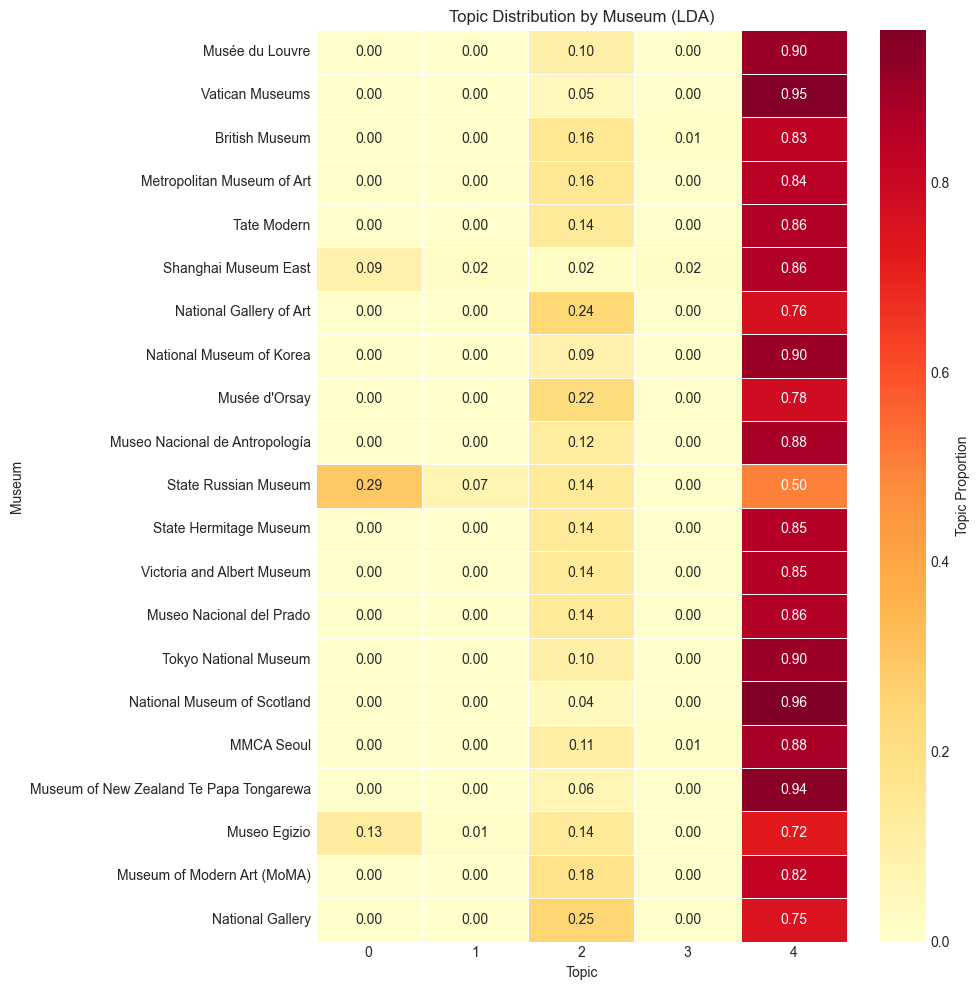

In [10]:
# 토픽 분포 히트맵
topic_vis = topic_by_museum.copy()
topic_vis.index = topic_vis.index.map(
    dict(zip(info['id'], info['museum']))
)

plt.figure(figsize=(10, 10))
sns.heatmap(topic_vis, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Topic Proportion'})
plt.xlabel('Topic')
plt.ylabel('Museum')
plt.title('Topic Distribution by Museum (LDA)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}figures/topic_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 유료 vs 무료 박물관 비교

In [13]:
# 유료/무료 그룹 비교
museum_sent_full = museum_sent.copy()

free_museums = museum_sent_full[museum_sent_full['admission_free_yn'] == 'Y']
paid_museums = museum_sent_full[museum_sent_full['admission_free_yn'] == 'N']

print('=== 유료 vs 무료 박물관 감성 비교 ===')
print(f'\n무료 박물관 ({len(free_museums)}개):')
print(f'  평균 감성: {free_museums["avg_sentiment"].mean():.3f}')
print(f'  평균 별점: {free_museums["avg_stars"].mean():.2f}')
print(f'  긍정 비율: {free_museums["positive_pct"].mean():.1f}%')
print(f'  부정 비율: {free_museums["negative_pct"].mean():.1f}%')

print(f'\n유료 박물관 ({len(paid_museums)}개):')
print(f'  평균 감성: {paid_museums["avg_sentiment"].mean():.3f}')
print(f'  평균 별점: {paid_museums["avg_stars"].mean():.2f}')
print(f'  긍정 비율: {paid_museums["positive_pct"].mean():.1f}%')
print(f'  부정 비율: {paid_museums["negative_pct"].mean():.1f}%')

diff = free_museums['avg_sentiment'].mean() - paid_museums['avg_sentiment'].mean()
print(f'\n감성 차이 (무료-유료): {diff:+.3f}')

=== 유료 vs 무료 박물관 감성 비교 ===

무료 박물관 (8개):
  평균 감성: 0.833
  평균 별점: 4.79
  긍정 비율: 91.4%
  부정 비율: 2.5%

유료 박물관 (13개):
  평균 감성: 0.576
  평균 별점: 4.60
  긍정 비율: 69.9%
  부정 비율: 6.1%

감성 차이 (무료-유료): +0.256


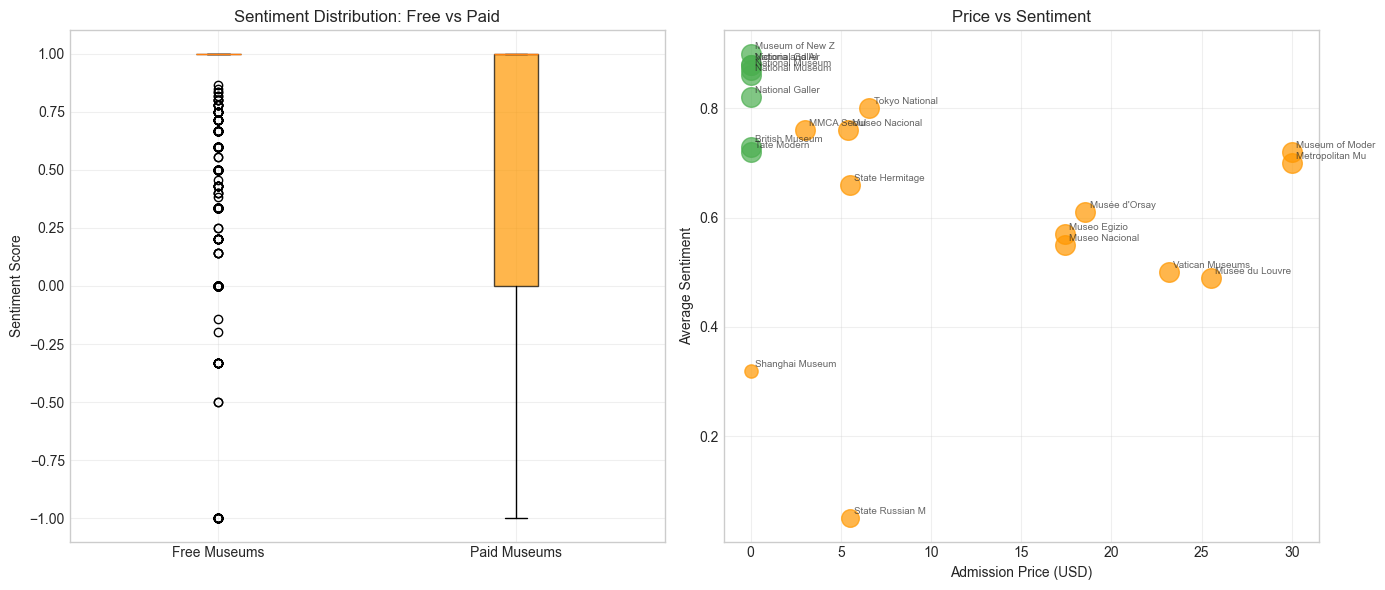

In [ ]:
# 유료 vs 무료: 감성 분포 비교 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 박스플롯
free_sentiments = df[df['museum_id'].isin(free_museums['museum_id'])]['sentiment']
paid_sentiments = df[df['museum_id'].isin(paid_museums['museum_id'])]['sentiment']

# ANCHOR 이전
# ax1.boxplot([free_sentiments.dropna(), paid_sentiments.dropna()],
#             labels=['Free Museums', 'Paid Museums'],
#             patch_artist=True,
#             boxprops=[dict(facecolor='#4CAF50', alpha=0.7),
#                       dict(facecolor='#FF9800', alpha=0.7)])
# ANCHOR 수정한 코드 /*
# 수정된 부분 1: 결과를 bp 변수에 받고, 안에서 boxprops 속성을 제거합니다.
bp = ax1.boxplot([free_sentiments.dropna(), paid_sentiments.dropna()],
                 labels=['Free Museums', 'Paid Museums'],
                 patch_artist=True)
# 수정된 부분 2: 생성된 각 박스에 대해 반복문으로 개별적인 색상과 투명도를 적용합니다.
colors = ['#4CAF50', '#FF9800']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
#  */

ax1.set_ylabel('Sentiment Score')
ax1.set_title('Sentiment Distribution: Free vs Paid')
ax1.grid(True, alpha=0.3)

# 입장료 vs 감성 산점도
for _, r in museum_sent_full.iterrows():
    ax2.scatter(r['adult_price_local_usd'], r['avg_sentiment'],
               s=r['review_count'], alpha=0.7,
               c='#4CAF50' if r['admission_free_yn'] == 'Y' else '#FF9800')
    ax2.annotate(r['museum'][:15], (r['adult_price_local_usd'], r['avg_sentiment']),
                fontsize=7, alpha=0.7, xytext=(3, 3), textcoords='offset points')

ax2.set_xlabel('Admission Price (USD)')
ax2.set_ylabel('Average Sentiment')
ax2.set_title('Price vs Sentiment')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}figures/free_vs_paid_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. 인사이트 & 결과 저장

In [16]:
# 국립중앙박물관 vs 유사 박물관 비교
nmk_sent = museum_sent_full[museum_sent_full['museum_id'] == 1008].iloc[0]

print('=== 국립중앙박물관 감성분석 결과 ===')
print(f'  평균 감성: {nmk_sent["avg_sentiment"]:.3f}')
print(f'  평균 별점: {nmk_sent["avg_stars"]:.2f}')
print(f'  긍정 비율: {nmk_sent["positive_pct"]:.1f}%')
print(f'  부정 비율: {nmk_sent["negative_pct"]:.1f}%')

# 전체 순위
rank = museum_sent_full.sort_values('avg_sentiment', ascending=False).reset_index(drop=True)
nmk_rank = rank[rank['museum_id'] == 1008].index[0] + 1
print(f'  감성 순위: {nmk_rank}/{len(rank)}')

print(f'\n=== 유료 전환 시 시사점 ===')
print(f'  - 국립중앙박물관은 이미 높은 감성 점수를 보유')
print(f'  - 유료 전환 시 "가격 대비 가치" 관련 부정 리뷰 증가 가능')
print(f'  - 유료 박물관 중 부정 비율이 높은 곳: 루브르({museum_sent_full[museum_sent_full["museum_id"]==1001]["negative_pct"].values[0]:.1f}%), 바티칸({museum_sent_full[museum_sent_full["museum_id"]==1002]["negative_pct"].values[0]:.1f}%)')
print(f'  - 이들은 높은 가격($25+)과 과밀(crowded)이 주요 불만 요인')

=== 국립중앙박물관 감성분석 결과 ===
  평균 감성: 0.860
  평균 별점: 4.85
  긍정 비율: 93.5%
  부정 비율: 0.5%
  감성 순위: 5/21

=== 유료 전환 시 시사점 ===
  - 국립중앙박물관은 이미 높은 감성 점수를 보유
  - 유료 전환 시 "가격 대비 가치" 관련 부정 리뷰 증가 가능
  - 유료 박물관 중 부정 비율이 높은 곳: 루브르(12.5%), 바티칸(11.5%)
  - 이들은 높은 가격($25+)과 과밀(crowded)이 주요 불만 요인


In [17]:
# 결과 저장
df.to_csv(f'{OUTPUT_DIR}sentiment_result.csv', index=False)
museum_sent_full.to_csv(f'{OUTPUT_DIR}museum_sentiment_summary.csv', index=False)
topic_by_museum.to_csv(f'{OUTPUT_DIR}museum_topic_distribution.csv')

print('✅ 저장 완료:')
print(f'  - sentiment_result.csv (리뷰별 감성 점수)')
print(f'  - museum_sentiment_summary.csv (박물관별 요약)')
print(f'  - museum_topic_distribution.csv (박물관별 토픽 분포)')

✅ 저장 완료:
  - sentiment_result.csv (리뷰별 감성 점수)
  - museum_sentiment_summary.csv (박물관별 요약)
  - museum_topic_distribution.csv (박물관별 토픽 분포)
